# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:** Kunal Ranjan  
**`Roll Number`:**  U20230022
**`GitHub Branch`:** Kunal_U20230022

# Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from rlcmab_sampler import sampler


# Load Datasets

In [3]:
#Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [4]:
print("Missing values in train_users:\n", train_users.isnull().sum())
print("\nMissing values in test_users:\n", test_users.isnull().sum())

#Fill missing age with median from training set
age_median = train_users['age'].median()
train_users['age'] = train_users['age'].fillna(age_median)
test_users['age'] = test_users['age'].fillna(age_median)

#Encoding label
le = LabelEncoder()
train_users['label_encoded'] = le.fit_transform(train_users['label'])
print("\nLabel mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

feature_cols = ['age', 'income', 'clicks', 'purchase_amount']

X_train = train_users[feature_cols].values
y_train = train_users['label_encoded'].values

X_test = test_users[feature_cols].values


print(f"\nTraining set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set:     X={X_test.shape} (no labels)")
print(f"\nClass distribution (train):\n{train_users['label'].value_counts()}")

Missing values in train_users:
 user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score                 0
loyalty_index                    0
screen_brightness                0
battery_percentage               0
cart_abandonment_count           0
browser_version                  0
background_app_count   

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler


train_users['subscriber'] = train_users['subscriber'].astype(int)
test_users['subscriber'] = test_users['subscriber'].astype(int)

#OneHotEncocing for categorical columns
categorical_cols = ['browser_version', 'region_code']

train_encoded = pd.get_dummies(train_users, columns=categorical_cols, dtype=int)
test_encoded  = pd.get_dummies(test_users,  columns=categorical_cols, dtype=int)

#Aligning
common_cols = train_encoded.columns.intersection(test_encoded.columns)
train_encoded = train_encoded[common_cols]
test_encoded  = test_encoded[common_cols]

#drops
drop_cols = ['user_id', 'label', 'label_encoded']
feature_cols_v2 = [c for c in train_encoded.columns if c not in drop_cols]

print(f"Total features used: {len(feature_cols_v2)}")
print(f"  (includes {sum(1 for c in feature_cols_v2 if c.startswith('browser_version_'))} browser_version dummies, "
      f"{sum(1 for c in feature_cols_v2 if c.startswith('region_code_'))} region_code dummies)")

X_full = train_encoded[feature_cols_v2].values
X_test_full = test_encoded[feature_cols_v2].values

X_tr, X_val, y_tr, y_val = train_test_split(X_full, y_train, test_size=0.2, random_state=42, stratify=y_train)

#Scaling
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

#Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=15)
dt_clf.fit(X_tr_scaled, y_tr)
dt_acc = accuracy_score(y_val, dt_clf.predict(X_val_scaled))

#Logistic Regression
lr_clf = LogisticRegression(max_iter=3000, random_state=42, C=1.0, solver='lbfgs')
lr_clf.fit(X_tr_scaled, y_tr)
lr_acc = accuracy_score(y_val, lr_clf.predict(X_val_scaled))

#Random Forest
rf_clf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42)
rf_clf.fit(X_tr_scaled, y_tr)
rf_acc = accuracy_score(y_val, rf_clf.predict(X_val_scaled))

#Comparison
print("\nModel Comparison (on 20% validation split)")
print(f"Decision Tree       accuracy: {dt_acc:.4f}")
print(f"Logistic Reg.       accuracy: {lr_acc:.4f}")
print(f"Random Forest       accuracy: {rf_acc:.4f}")

#Best pick
best_name, best_acc, best_clf, uses_scaler = max(
    [("Decision Tree", dt_acc, dt_clf, False),
     ("Logistic Regression", lr_acc, lr_clf, True),
     ("Random Forest", rf_acc, rf_clf, False)],
    key=lambda x: x[1]
)
print(f"\nBest model: {best_name} ({best_acc:.4f})")

#Refit best model on full training data for later use
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_full)
X_test_scaled = scaler.transform(X_test_full)
best_clf.fit(X_train_scaled, y_train)

#Storing the best classifier for later use, since accuracy is close, can try both rf and lr for contextual bandits
context_classifier = best_clf

def predict_user_context(features):
    """Predict user category (0=user1, 1=user2, 2=user3) from raw features."""
    features = np.array(features).reshape(1, -1)
    if uses_scaler:
        features = scaler.transform(features)
    return context_classifier.predict(features)[0]

Total features used: 134
  (includes 37 browser_version dummies, 68 region_code dummies)

Model Comparison (on 20% validation split)
Decision Tree       accuracy: 0.8350
Logistic Reg.       accuracy: 0.9200
Random Forest       accuracy: 0.8975

Best model: Logistic Regression (0.9200)


In [6]:
from sklearn.metrics import classification_report

y_val_pred = best_clf.predict(X_val_scaled)
print("Classification Report (20% Validation Split):\n")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

Classification Report (20% Validation Split):

              precision    recall  f1-score   support

      user_1       0.91      0.87      0.89       142
      user_2       0.98      0.91      0.95       142
      user_3       0.88      1.00      0.94       116

    accuracy                           0.92       400
   macro avg       0.92      0.93      0.92       400
weighted avg       0.93      0.92      0.92       400



# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm
and sweeps over multiple e values to compare expected payoffs.

Epsilon-Greedy Hyperparameter Comparison (T=10000)

  e=0.01   overall avg reward = 5.6316
    user_1: best arm = Crime (Q=5.4043), pulls = [  13   25   10 3286]
    user_2: best arm = Education (Q=3.7633), pulls = [  13 3302   13    5]
    user_3: best arm = Crime (Q=7.9462), pulls = [ 273    6    3 3051]

  e=0.1    overall avg reward = 5.2039
    user_1: best arm = Crime (Q=5.4385), pulls = [  85  119   84 3046]
    user_2: best arm = Education (Q=3.7736), pulls = [ 103 3031  119   80]
    user_3: best arm = Crime (Q=7.9315), pulls = [ 268   87   78 2900]

  e=0.3    overall avg reward = 4.2803
    user_1: best arm = Crime (Q=5.4806), pulls = [ 275  292  236 2531]
    user_2: best arm = Education (Q=3.7737), pulls = [ 255 2556  272  250]
    user_3: best arm = Crime (Q=7.9183), pulls = [ 271  243  277 2542]

  e=0.5    overall avg reward = 3.3692
    user_1: best arm = Crime (Q=5.4422), pulls = [ 407  421  448 2058]
    user_2: best arm = Education (Q=3.7792), pulls = [ 425 2075  42

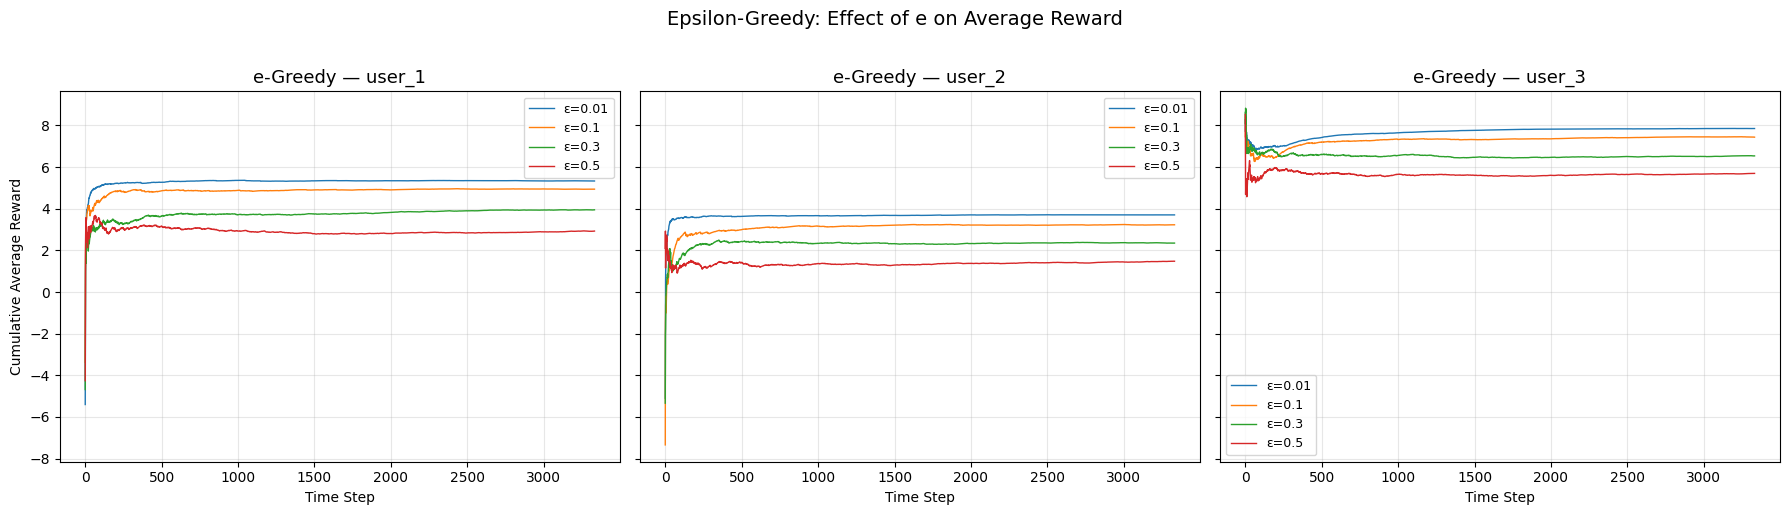

In [19]:

#e-greedy contextual bandit

#following arm mapping

NEWS_CATEGORIES = ["Entertainment", "Education", "Tech", "Crime"]
NUM_CATEGORIES = len(NEWS_CATEGORIES)
NUM_CONTEXTS = 3
CONTEXT_NAMES = ["user_1", "user_2", "user_3"]

def arm_index(context, category):
    return context * NUM_CATEGORIES + category


def epsilon_greedy(T, epsilon, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    reward_sampler = sampler(22)
    counts = np.zeros((NUM_CONTEXTS, NUM_CATEGORIES))
    values = np.zeros((NUM_CONTEXTS, NUM_CATEGORIES))
    rewards_per_context = {c: [] for c in range(NUM_CONTEXTS)}

    for t in range(T):
        ctx = t % NUM_CONTEXTS                     #cycle contexts
        if rng.random() < epsilon:                  #explore
            cat = rng.integers(NUM_CATEGORIES)
        else:                                       #exploit
            cat = int(np.argmax(values[ctx]))

        reward = reward_sampler.sample(arm_index(ctx, cat))
        counts[ctx, cat] += 1
        #incremental mean update
        values[ctx, cat] += (reward - values[ctx, cat]) / counts[ctx, cat]
        rewards_per_context[ctx].append(reward)

    return rewards_per_context, counts, values


# Helper: running average
def running_avg(rewards):
    return np.cumsum(rewards) / np.arange(1, len(rewards) + 1)


#experiment
T = 10_000
EPSILON_VALUES = [0.01, 0.1, 0.3, 0.5]

eg_results = {}
for eps in EPSILON_VALUES:
    rw, cnt, qv = epsilon_greedy(T, eps, rng=np.random.default_rng(42))
    eg_results[eps] = {"rewards": rw, "counts": cnt, "values": qv}

print(f"Epsilon-Greedy Hyperparameter Comparison (T={T})\n")
for eps in EPSILON_VALUES:
    res = eg_results[eps]
    overall_avg = np.mean([r for c in range(NUM_CONTEXTS) for r in res["rewards"][c]])
    print(f"  e={eps:<5}  overall avg reward = {overall_avg:.4f}")
    for c in range(NUM_CONTEXTS):
        best = int(np.argmax(res["values"][c]))
        print(f"    {CONTEXT_NAMES[c]}: best arm = {NEWS_CATEGORIES[best]} "
              f"(Q={res['values'][c, best]:.4f}), pulls = {res['counts'][c].astype(int)}")
    print()


best_eps = max(eg_results, key=lambda e: np.mean(
    [r for c in range(NUM_CONTEXTS) for r in eg_results[e]["rewards"][c]]))
print(f"Best e = {best_eps}")

#Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for c in range(NUM_CONTEXTS):
    ax = axes[c]
    for eps in EPSILON_VALUES:
        rw = eg_results[eps]["rewards"][c]
        ax.plot(running_avg(rw), label=f"ε={eps}", linewidth=1)
    ax.set_title(f"e-Greedy — {CONTEXT_NAMES[c]}", fontsize=13)
    ax.set_xlabel("Time Step")
    if c == 0:
        ax.set_ylabel("Cumulative Average Reward")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle("Epsilon-Greedy: Effect of e on Average Reward", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits
and sweeps over multiple $C$ values to compare expected payoffs.

UCB Hyperparameter Comparison (T=10000)

  C=0.5    overall avg reward = 5.6915
    user_1: best arm = Crime (Q=5.4374), pulls = [   1    3    1 3329]
    user_2: best arm = Education (Q=3.7599), pulls = [   1 3328    3    1]
    user_3: best arm = Crime (Q=7.8954), pulls = [   2    1    1 3329]

  C=1.0    overall avg reward = 5.7056
    user_1: best arm = Crime (Q=5.4359), pulls = [   1    6    1 3326]
    user_2: best arm = Education (Q=3.7664), pulls = [   1 3328    3    1]
    user_3: best arm = Crime (Q=7.9346), pulls = [   2    1    1 3329]

  C=2.0    overall avg reward = 5.7134
    user_1: best arm = Crime (Q=5.4589), pulls = [   1   22    1 3310]
    user_2: best arm = Education (Q=3.7667), pulls = [   1 3321    9    2]
    user_3: best arm = Crime (Q=7.9517), pulls = [  25    1    1 3306]

  C=5.0    overall avg reward = 5.6510
    user_1: best arm = Crime (Q=5.4363), pulls = [   3  144    3 3184]
    user_2: best arm = Education (Q=3.7546), pulls = [   3 3290   32    8]
   

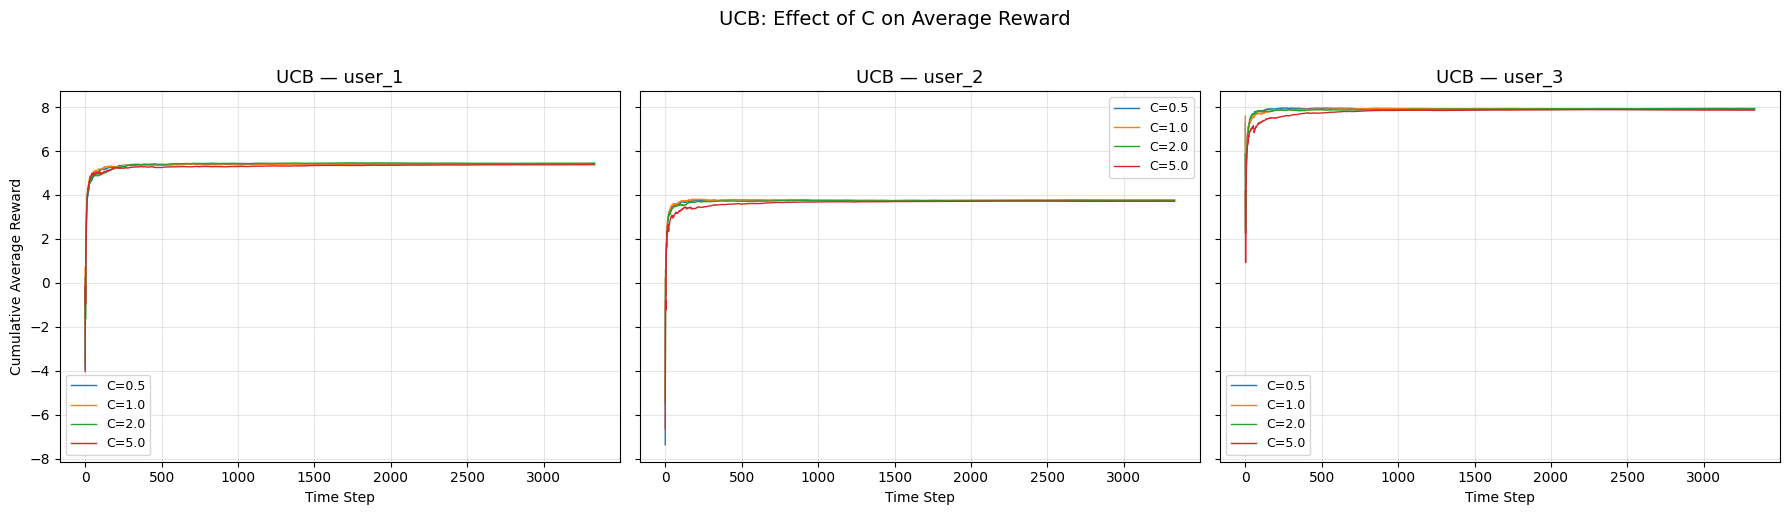

In [14]:

#UCB


def ucb(T, C, rng=None):

    if rng is None:
        rng = np.random.default_rng(42)

    counts = np.zeros((NUM_CONTEXTS, NUM_CATEGORIES))
    values = np.zeros((NUM_CONTEXTS, NUM_CATEGORIES))
    rewards_per_context = {c: [] for c in range(NUM_CONTEXTS)}

    total_per_ctx = np.zeros(NUM_CONTEXTS)
    reward_sampler = sampler(22)
    for t in range(T):
        ctx = t % NUM_CONTEXTS
        total_per_ctx[ctx] += 1

        #Ensure each arm is tried at least once per context
        if np.any(counts[ctx] == 0):
            cat = int(np.argmin(counts[ctx]))
        else:
            ucb_vals = values[ctx] + C * np.sqrt(
                np.log(total_per_ctx[ctx]) / counts[ctx]
            )
            cat = int(np.argmax(ucb_vals))

        reward = reward_sampler.sample(arm_index(ctx, cat))
        counts[ctx, cat] += 1
        values[ctx, cat] += (reward - values[ctx, cat]) / counts[ctx, cat]
        rewards_per_context[ctx].append(reward)

    return rewards_per_context, counts, values


#experiment
C_VALUES = [0.5, 1.0, 2.0, 5.0]

ucb_results = {}
for C in C_VALUES:
    rw, cnt, qv = ucb(T, C, rng=np.random.default_rng(42))
    ucb_results[C] = {"rewards": rw, "counts": cnt, "values": qv}

print(f"UCB Hyperparameter Comparison (T={T})\n")
for C in C_VALUES:
    res = ucb_results[C]
    overall_avg = np.mean([r for c in range(NUM_CONTEXTS) for r in res["rewards"][c]])
    print(f"  C={C:<5}  overall avg reward = {overall_avg:.4f}")
    for c in range(NUM_CONTEXTS):
        best = int(np.argmax(res["values"][c]))
        print(f"    {CONTEXT_NAMES[c]}: best arm = {NEWS_CATEGORIES[best]} "
              f"(Q={res['values'][c, best]:.4f}), pulls = {res['counts'][c].astype(int)}")
    print()


best_C = max(ucb_results, key=lambda c_: np.mean(
    [r for c in range(NUM_CONTEXTS) for r in ucb_results[c_]["rewards"][c]]))
print(f"Best C = {best_C}")

#Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for c in range(NUM_CONTEXTS):
    ax = axes[c]
    for C in C_VALUES:
        rw = ucb_results[C]["rewards"][c]
        ax.plot(running_avg(rw), label=f"C={C}", linewidth=1)
    ax.set_title(f"UCB — {CONTEXT_NAMES[c]}", fontsize=13)
    ax.set_xlabel("Time Step")
    if c == 0:
        ax.set_ylabel("Cumulative Average Reward")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle("UCB: Effect of C on Average Reward", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## SoftMax Strategy

This section implements the SoftMax strategy and sweeps over
multiple temperature $\tau$ values to compare expected payoffs.

SoftMax Hyperparameter Comparison (T=10000)

  t=0.1    overall avg reward = 5.7079
    user_1: best arm = Crime (Q=5.4417), pulls = [   0    0    0 3334]
    user_2: best arm = Education (Q=3.7497), pulls = [   0 3333    0    0]
    user_3: best arm = Crime (Q=7.9324), pulls = [   0    0    0 3333]

  t=0.5    overall avg reward = 5.6901
    user_1: best arm = Crime (Q=5.4201), pulls = [   0    0    0 3334]
    user_2: best arm = Education (Q=3.7610), pulls = [   0 3262   71    0]
    user_3: best arm = Crime (Q=7.9357), pulls = [   0    0    0 3333]

  t=1.0    overall avg reward = 5.5146
    user_1: best arm = Crime (Q=5.4291), pulls = [   1  890    3 2440]
    user_2: best arm = Education (Q=3.7507), pulls = [   1 2964  353   15]
    user_3: best arm = Crime (Q=7.9278), pulls = [   0    6    0 3327]

  t=5.0    overall avg reward = 3.7853
    user_1: best arm = Crime (Q=5.4529), pulls = [ 264 1286  246 1538]
    user_2: best arm = Education (Q=3.8111), pulls = [ 197 1603 1015  518]

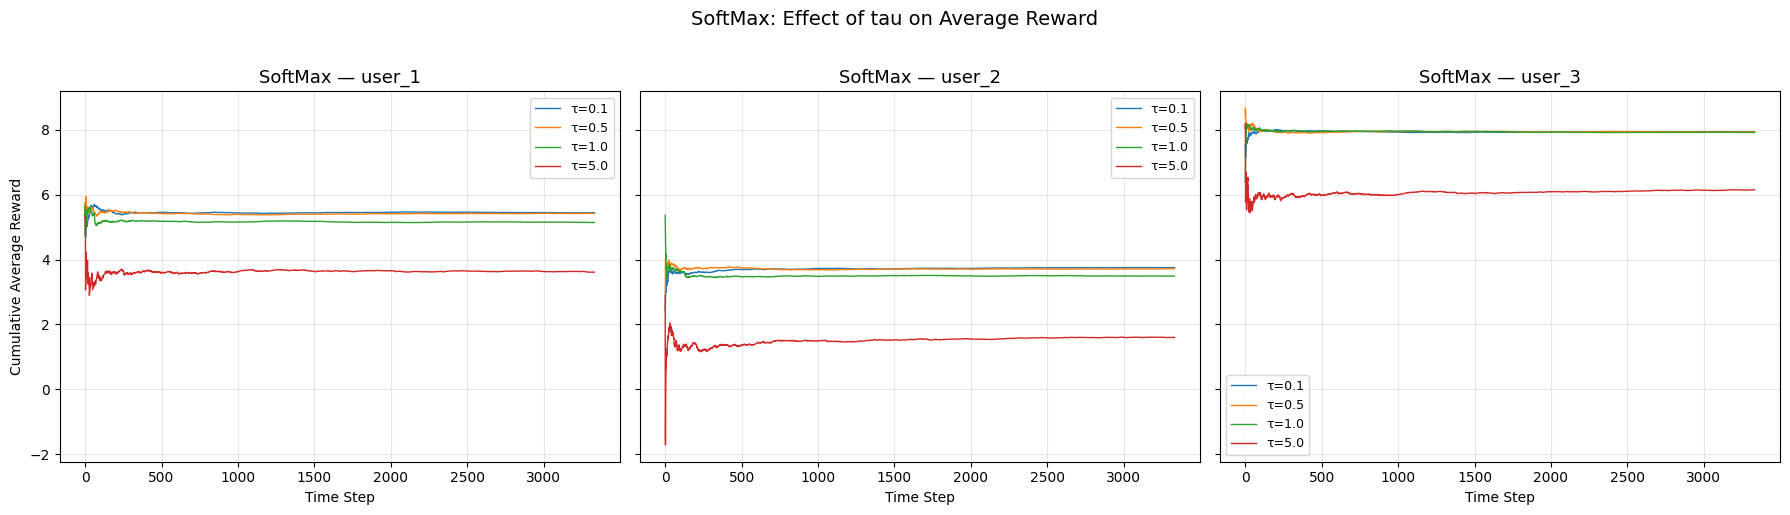

In [21]:
#SoftMax Strategy


def softmax_bandit(T, tau=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    counts = np.zeros((NUM_CONTEXTS, NUM_CATEGORIES))
    values = np.zeros((NUM_CONTEXTS, NUM_CATEGORIES))
    rewards_per_context = {c: [] for c in range(NUM_CONTEXTS)}
    reward_sampler = sampler(22)
    for t in range(T):
        ctx = t % NUM_CONTEXTS

       
        logits = values[ctx] / tau
        logits -= logits.max()                    #numerical stability
        exp_logits = np.exp(logits)
        probs = exp_logits / exp_logits.sum()

        cat = rng.choice(NUM_CATEGORIES, p=probs)

        reward = reward_sampler.sample(arm_index(ctx, cat))
        counts[ctx, cat] += 1
        values[ctx, cat] += (reward - values[ctx, cat]) / counts[ctx, cat]
        rewards_per_context[ctx].append(reward)

    return rewards_per_context, counts, values


#experiment
TAU_VALUES = [0.1, 0.5, 1.0, 5.0]

sm_results = {}
for tau in TAU_VALUES:
    rw, cnt, qv = softmax_bandit(T, tau=tau, rng=np.random.default_rng(42))
    sm_results[tau] = {"rewards": rw, "counts": cnt, "values": qv}

print(f"SoftMax Hyperparameter Comparison (T={T})\n")
for tau in TAU_VALUES:
    res = sm_results[tau]
    overall_avg = np.mean([r for c in range(NUM_CONTEXTS) for r in res["rewards"][c]])
    print(f"  t={tau:<5}  overall avg reward = {overall_avg:.4f}")
    for c in range(NUM_CONTEXTS):
        best = int(np.argmax(res["values"][c]))
        print(f"    {CONTEXT_NAMES[c]}: best arm = {NEWS_CATEGORIES[best]} "
              f"(Q={res['values'][c, best]:.4f}), pulls = {res['counts'][c].astype(int)}")
    print()


best_tau = max(sm_results, key=lambda t: np.mean(
    [r for c in range(NUM_CONTEXTS) for r in sm_results[t]["rewards"][c]]))
print(f"Best t = {best_tau}")

#comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for c in range(NUM_CONTEXTS):
    ax = axes[c]
    for tau in TAU_VALUES:
        rw = sm_results[tau]["rewards"][c]
        ax.plot(running_avg(rw), label=f"τ={tau}", linewidth=1)
    ax.set_title(f"SoftMax — {CONTEXT_NAMES[c]}", fontsize=13)
    ax.set_xlabel("Time Step")
    if c == 0:
        ax.set_ylabel("Cumulative Average Reward")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle("SoftMax: Effect of tau on Average Reward", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [22]:

#Using the best hyperparameters identified from sweeps above

T = 10_000

print(f"Best hyperparameters from sweeps:")
print(f"  e-Greedy:  e = {best_eps}")
print(f"  UCB:       C = {best_C}")
print(f"  SoftMax:   tau = {best_tau}")
print()

#Run each algorithm with its best hyperparameter
rw_eg_best, cnt_eg_best, qv_eg_best = epsilon_greedy(T, best_eps, rng=np.random.default_rng(42))
rw_ucb_best, cnt_ucb_best, qv_ucb_best = ucb(T, best_C, rng=np.random.default_rng(42))
rw_sm_best, cnt_sm_best, qv_sm_best = softmax_bandit(T, tau=best_tau, rng=np.random.default_rng(42))

sim_results = {
    f"e-Greedy (e={best_eps})": {"rewards": rw_eg_best, "counts": cnt_eg_best, "values": qv_eg_best},
    f"UCB (C={best_C})":        {"rewards": rw_ucb_best, "counts": cnt_ucb_best, "values": qv_ucb_best},
    f"SoftMax (tau={best_tau})":   {"rewards": rw_sm_best, "counts": cnt_sm_best, "values": qv_sm_best},
}

for name, res in sim_results.items():
    overall_avg = np.mean([r for c in range(NUM_CONTEXTS) for r in res["rewards"][c]])
    print(f"{name}  →  overall avg reward = {overall_avg:.4f}")
    for c in range(NUM_CONTEXTS):
        best_arm = int(np.argmax(res["values"][c]))
        print(f"    {CONTEXT_NAMES[c]}: best arm = {NEWS_CATEGORIES[best_arm]} "
              f"(Q={res['values'][c, best_arm]:.4f}), pulls = {res['counts'][c].astype(int)}")
    print()

Best hyperparameters from sweeps:
  e-Greedy:  e = 0.01
  UCB:       C = 2.0
  SoftMax:   tau = 0.1

e-Greedy (e=0.01)  →  overall avg reward = 5.5543
    user_1: best arm = Crime (Q=5.4427), pulls = [  13   25   10 3286]
    user_2: best arm = Education (Q=3.7473), pulls = [  13 3302   13    5]
    user_3: best arm = Crime (Q=7.9215), pulls = [1158    6    3 2166]

UCB (C=2.0)  →  overall avg reward = 5.7164
    user_1: best arm = Crime (Q=5.4654), pulls = [   1   28    1 3304]
    user_2: best arm = Education (Q=3.7676), pulls = [   1 3321   10    1]
    user_3: best arm = Crime (Q=7.9538), pulls = [  32    1    1 3299]

SoftMax (tau=0.1)  →  overall avg reward = 5.7012
    user_1: best arm = Crime (Q=5.4251), pulls = [   0    0    0 3334]
    user_2: best arm = Education (Q=3.7357), pulls = [   0 3333    0    0]
    user_3: best arm = Crime (Q=7.9427), pulls = [   0    0    0 3333]



## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


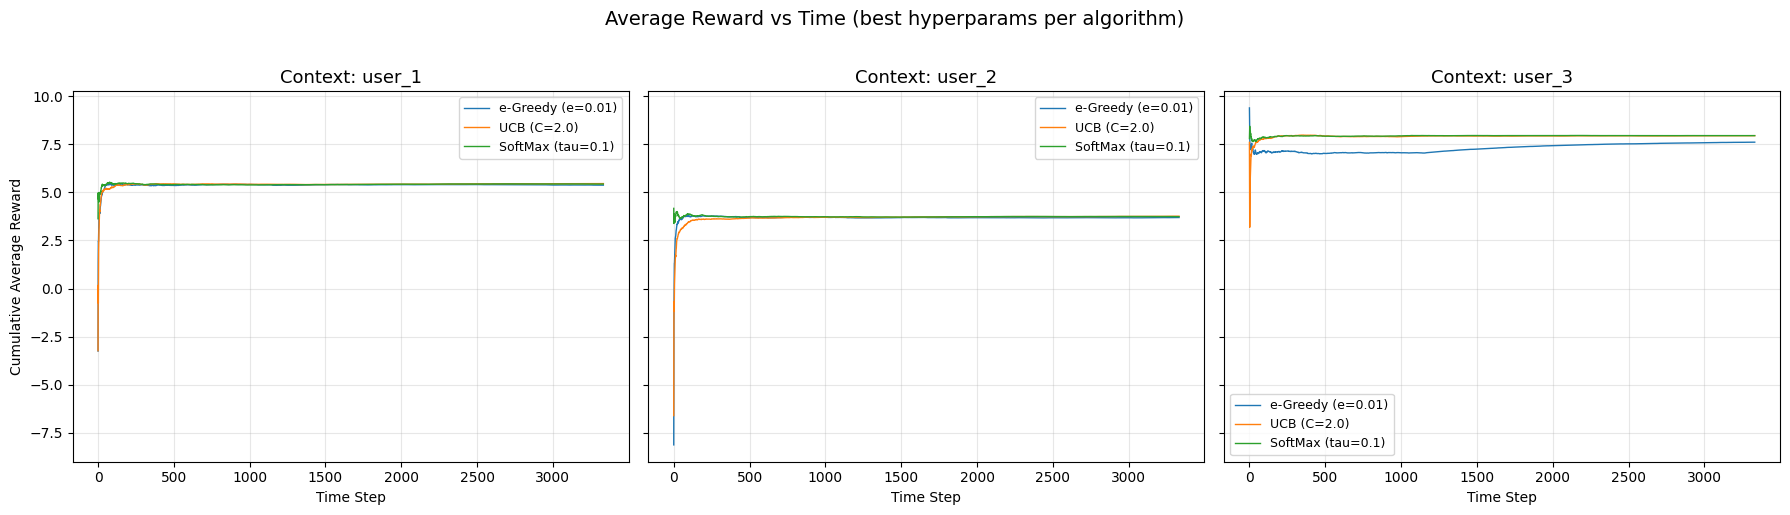

In [23]:

#PLOT 1: Average Reward vs Time — per context (best hyperparams)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for c in range(NUM_CONTEXTS):
    ax = axes[c]
    for name, res in sim_results.items():
        ax.plot(running_avg(res["rewards"][c]), label=name, linewidth=1)
    ax.set_title(f"Context: {CONTEXT_NAMES[c]}", fontsize=13)
    ax.set_xlabel("Time Step")
    if c == 0:
        ax.set_ylabel("Cumulative Average Reward")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Average Reward vs Time (best hyperparams per algorithm)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

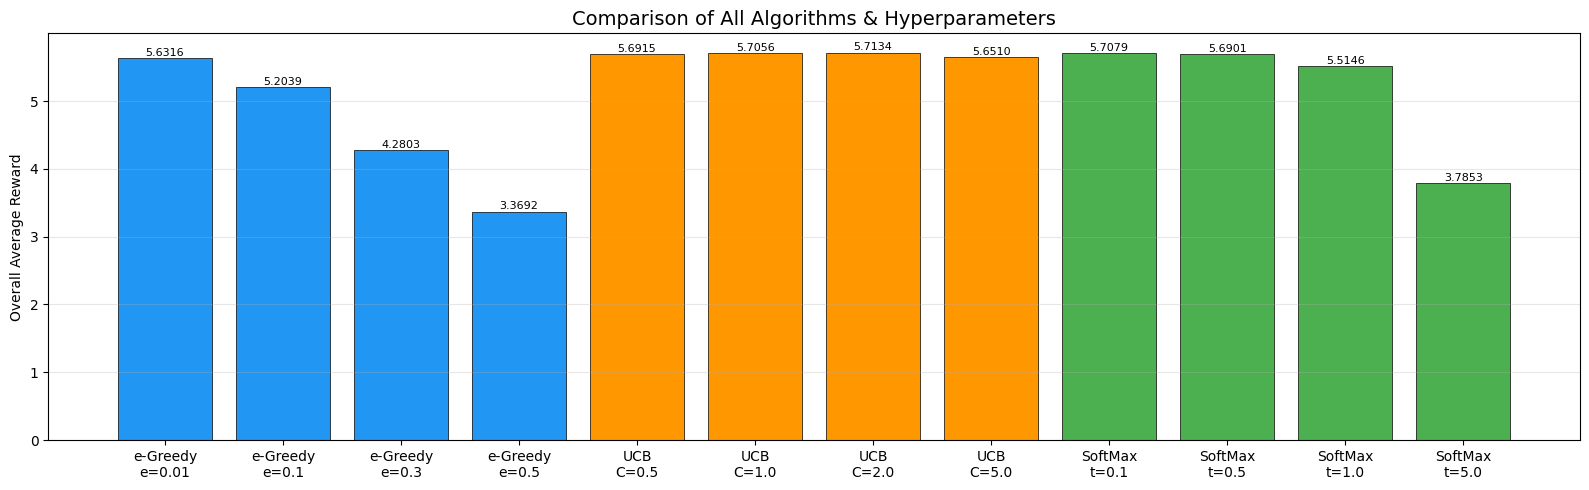

In [24]:

# PLOT 2: Bar chart — all hyperparameters across all 3 algorithms

labels = []
avg_rewards = []

for eps in EPSILON_VALUES:
    all_rw = [r for c in range(NUM_CONTEXTS) for r in eg_results[eps]["rewards"][c]]
    labels.append(f"e-Greedy\ne={eps}")
    avg_rewards.append(np.mean(all_rw))

for C in C_VALUES:
    all_rw = [r for c in range(NUM_CONTEXTS) for r in ucb_results[C]["rewards"][c]]
    labels.append(f"UCB\nC={C}")
    avg_rewards.append(np.mean(all_rw))

for tau in TAU_VALUES:
    all_rw = [r for c in range(NUM_CONTEXTS) for r in sm_results[tau]["rewards"][c]]
    labels.append(f"SoftMax\nt={tau}")
    avg_rewards.append(np.mean(all_rw))

colors = (["#2196F3"] * len(EPSILON_VALUES) +
          ["#FF9800"] * len(C_VALUES) +
          ["#4CAF50"] * len(TAU_VALUES))

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(labels, avg_rewards, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Overall Average Reward")
ax.set_title("Comparison of All Algorithms & Hyperparameters", fontsize=14)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, avg_rewards):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

## Recommendation Engine (Section 5.4)

End-to-end CMAB pipeline:
1. **Classify** user → context using the trained classifier
2. **Select** optimal news category using the trained bandit policy
3. **Recommend** a random article from that category

In [26]:
#Recommendation Engine

NEWS_CAT_MAP = {
    0: "ENTERTAINMENT",
    1: "EDUCATION",
    2: "TECH",
    3: "CRIME",
}

#Pick the best policy's Q-values (UCB with best C)
best_policy_qv = ucb_results[best_C]["values"]

def recommend_article(user_features_row, news_df, qv):
    #Classify user context
    feats = user_features_row.values.reshape(1, -1)
    feats_scaled = scaler.transform(feats)
    ctx = best_clf.predict(feats_scaled)[0]          #0, 1, or 2
    context_label = CONTEXT_NAMES[ctx]

    #Select optimal category via greedy policy
    best_cat_idx = int(np.argmax(qv[ctx]))
    selected_category = NEWS_CAT_MAP[best_cat_idx]

    #Randomly sample an article from that category
    pool = news_df[news_df["category"] == selected_category]
    if len(pool) == 0:
        article = "No articles found in this category"
    else:
        article = pool.sample(1, random_state=None).iloc[0]["headline"]

    return context_label, selected_category, article


#Run on test_users
test_features = test_encoded[feature_cols_v2]

recommendations = []
for idx in range(len(test_features)):
    row = test_features.iloc[idx]
    ctx_lbl, cat, headline = recommend_article(row, news_df, best_policy_qv)
    recommendations.append({
        "user_id": test_users.iloc[idx]["user_id"],
        "predicted_context": ctx_lbl,
        "recommended_category": cat,
        "article_headline": headline,
    })

rec_df = pd.DataFrame(recommendations)
print(f"Recommendations generated for {len(rec_df)} test users.\n")
print(rec_df.head(15).to_string(index=False))
print(f"\nCategory distribution in recommendations")
print(rec_df["recommended_category"].value_counts())

Recommendations generated for 2000 test users.

user_id predicted_context recommended_category                                                                                  article_headline
  U4058            user_3                CRIME                                    The 15 Most Bizarre Moments From The Jodi Arias Trial (So Far)
  U1118            user_1                CRIME                                                 Puerto Rico Policeman Kills Three Fellow Officers
  U6555            user_1                CRIME                                                       Trayvon Martin and Race: A Sober Assessment
  U9170            user_1                CRIME                                      Man, 21, Arrested A Week After 3 Killed At Georgia Gun Range
  U3348            user_1                CRIME                              Interrogators Speak Out: Torture is Illegal, Immoral and Ineffective
  U2244            user_3                CRIME                          World's 2n

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


In [27]:

# Final Summary Table


print("FINAL COMPARATIVE ANALYSIS")


#Build summary
rows = []
for eps in EPSILON_VALUES:
    all_rw = [r for c in range(NUM_CONTEXTS) for r in eg_results[eps]["rewards"][c]]
    rows.append({"Algorithm": "ε-Greedy", "Hyperparam": f"e={eps}",
                 "Avg Reward": np.mean(all_rw)})
for C in C_VALUES:
    all_rw = [r for c in range(NUM_CONTEXTS) for r in ucb_results[C]["rewards"][c]]
    rows.append({"Algorithm": "UCB", "Hyperparam": f"C={C}",
                 "Avg Reward": np.mean(all_rw)})
for tau in TAU_VALUES:
    all_rw = [r for c in range(NUM_CONTEXTS) for r in sm_results[tau]["rewards"][c]]
    rows.append({"Algorithm": "SoftMax", "Hyperparam": f"t={tau}",
                 "Avg Reward": np.mean(all_rw)})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

FINAL COMPARATIVE ANALYSIS
Algorithm Hyperparam  Avg Reward
 ε-Greedy     e=0.01    5.631579
 ε-Greedy      e=0.1    5.203913
 ε-Greedy      e=0.3    4.280282
 ε-Greedy      e=0.5    3.369168
      UCB      C=0.5    5.691533
      UCB      C=1.0    5.705626
      UCB      C=2.0    5.713367
      UCB      C=5.0    5.651046
  SoftMax      t=0.1    5.707907
  SoftMax      t=0.5    5.690073
  SoftMax      t=1.0    5.514630
  SoftMax      t=5.0    3.785255


## Key Observations

1. **Epsilon-Greedy** (tested e ∈ {0.01, 0.1, 0.3, 0.5}):
   - Lower e (e.g., 0.01) leads to higher exploitation and faster convergence to the optimal arm, but risks getting stuck in local optima.
   - Higher e (e.g., 0.5) maintains more exploration, yielding lower average reward but better arm estimates.

2. **UCB** (tested C ∈ {0.5, 1.0, 2.0, 5.0}):
   - Automatically balances exploration/exploitation via the confidence bound.
   - Smaller C values (0.5) favor exploitation; larger C (5.0) over-explores.
   - Generally more robust than ε-Greedy as it adapts exploration over time.

3. **SoftMax** (tested τ ∈ {0.1, 0.5, 1.0, 5.0}):
   - Lower tau (e.g., 0.1) makes selection nearly greedy — high exploitation, fast convergence, but limited exploration.
   - Higher tau (e.g., 5.0) flattens probabilities toward uniform random, increasing exploration at the cost of average reward.
   - Moderate tau values provide a good balance between exploration and exploitation.

4. **Context Sensitivity**:
   - Each user context has a distinct optimal category, validating the CMAB approach over a context-free bandit.
   - The classifier successfully segments users, enabling personalized category recommendations.